## **Figure-S20**

In [1]:
import pandas as pd
import polars as pl
from functools import reduce
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import sys
import numpy as np
import matplotlib as mpl
import os 
import re

from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker


sys.path.append("../../scripts")

from figure_utils import *

In [2]:
print("Pandas Version", pd.__version__)
print("Polars Version", pl.__version__)
print("numpy Version", np.__version__)
print("matplotlib version", mpl.__version__)
print("seaborn version", sns.__version__)
print("Python Version", sys.version)

Pandas Version 2.2.3
Polars Version 1.28.1
numpy Version 2.2.2
matplotlib version 3.10.0
seaborn version 0.13.2
Python Version 3.12.4 (main, Jun  7 2024, 23:47:47) [GCC 13.3.0]


---

---

In [3]:
names = dict(bruker='timsTOF\n2024',
             silico='in-silico',
             diatracer='Direct')

condition = dict(orig='Initial', refined='Reference-based')

In [4]:
# Use default mpl color cycle
default_colors = mpl.rcParams['axes.prop_cycle'].by_key()['color']

condition_palette = {
    condition['orig']: default_colors[0],
    condition['refined']: default_colors[1],
}


# **Load Data**

#### **Load Data - DIA-NN**

In [5]:
# Function to extract dilution and replicate from directory name
def extract_info(dirname: str) -> tuple:
    # Match patterns like 100ng_HeLa_Py3_DIA_1_... (replicate number after DIA_)
    dilution_match = re.search(r'_(\d+pg)_', dirname)
    replicate_match = re.search(r'PyDIA_(\d+)_', dirname)
    
    dilution = dilution_match.group(1) if dilution_match else "unknown"
    replicate = replicate_match.group(1) if replicate_match else "unknown"
    
    return dilution, replicate


def extract_lib_info(dirname: str):
    dilution_match = re.search(r'-(\d+pg)-', dirname)
    
    return dilution_match.group(1) if dilution_match else "unknown"

def loadRefinedFolderDiann(diann_dir, **kwargs):
    # Dictionary to store results by dilution and replicate
    rslts = {str(i):defaultdict(dict) for i in condition.values() }

    # Define custom sort order for dilutions
    dilution_order = ["100pg", "250pg", "500pg", "1000pg", '2500pg', '5000pg']

    # Get all dilution directories within diann directory
    dilution_dirs = []
    if os.path.isdir(diann_dir):
        dilution_dirs = [d for d in os.listdir(diann_dir) 
                        if os.path.isdir(os.path.join(diann_dir, d))
                        and re.match(r'100pg', d)]
    
    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(diann_dir, dilution_dir)

        # Get all replicate directories within this dilution directory
        replicate_dirs = [d for d in os.listdir(dilution_path) 
                         if os.path.isdir(os.path.join(dilution_path, d))]

        for replicate_dir in replicate_dirs:
            replicate_path = os.path.join(dilution_path, replicate_dir)

            # Extract replicate number
            _, replicate = extract_info(replicate_dir)

            # Look for library directories (ending with _lib)
            lib_dirs = [d for d in os.listdir(replicate_path) 
                       if os.path.isdir(os.path.join(replicate_path, d))
                       and d.endswith('_lib')]

            for lib_dir in lib_dirs:
                # Path to report.tsv
                report_path = os.path.join(replicate_path, lib_dir, "report.tsv")

                lib_dilution = extract_lib_info(lib_dir)

                # Check if file exists
                if os.path.exists(report_path):
                    try:
                        # Call getProteinSetDiann function
                        result = getProteinSetDiann(report_path, **kwargs)

                        if lib_dilution == '500pg':
                            # Store both the result and the library name
                            rslts[condition['refined']][replicate] = result

                            print(f"Processed {dilution_dir} rep {replicate} | lib dilution {lib_dilution} | lib directory {lib_dir}")
                    except Exception as e:
                        print(f"Error processing {report_path}: {str(e)}")
                        raise e
                else:
                    print(f"Missing report.tsv file in {os.path.join(replicate_path, lib_dir)}")
    return rslts


def appendOriginalResultsDiann(diann_dir, rslts, **kwargs):
    # Get all experiment directories within diann directory
    diann_experiment_dirs = []
    if os.path.isdir(diann_dir):
        diann_experiment_dirs = [d for d in os.listdir(diann_dir) 
                               if os.path.isdir(os.path.join(diann_dir, d)) and '_0pg' not in d and "R2024" not in d and '100pg' in d]
    
    # Process each directory
    for dir_name in diann_experiment_dirs:
        # Extract dilution and replicate
        dilution, replicate = extract_info(dir_name)
        
        # Path to report.tsv
        report_path = os.path.join(diann_dir, dir_name, "report.tsv")

        # Check if file exists
        if os.path.exists(report_path):
            try:
                # Call getPrecursorSertDiann function
                result = getProteinSetDiann(report_path, **kwargs)
                rslts[condition['orig']][replicate] = result

                print(f"Processed {dir_name} successfully (dilution: {dilution}, replicate: {replicate})")
            except Exception as e:
                print(f"Error processing {dir_name}: {str(e)}")
        else:
            print(f"Skipping {dir_name}: Missing report.tsv file")

diann = {}

diann[names['bruker']] = loadRefinedFolderDiann("../../results/SCP-Bruker-Lib-Refined-Analysis/diann")
appendOriginalResultsDiann("../../results/SCP-Bruker-Library-Analysis/diann/", diann[names['bruker']])

diann[names['silico']] = loadRefinedFolderDiann("../../results/SCP-PeptDeep-NoMods-Refined-Analysis/diann")
appendOriginalResultsDiann("../../results/SCP-PeptDeep-NoMods-Analysis/diann/", diann[names['silico']])

diann[names['diatracer']] = loadRefinedFolderDiann("../../results/SCP-diaTracer-Refined-Analysis/diann/", infer_schema_length=10000)
appendOriginalResultsDiann("../../results/SCP-diaTracer-Analysis/diann", diann[names['diatracer']], infer_schema_length=10000)

../../results/SCP-Bruker-Lib-Refined-Analysis/diann/100pg/HeLa02DDM_100pg_5x3_PyDIA_2_S1-C5_1_1631/2025-06-17-Refine-BrukerLib-5000pg-rep2_lib/report.tsv
../../results/SCP-Bruker-Lib-Refined-Analysis/diann/100pg/HeLa02DDM_100pg_5x3_PyDIA_2_S1-C5_1_1631/2025-06-17-Refine-BrukerLib-2500pg-rep2_lib/report.tsv
../../results/SCP-Bruker-Lib-Refined-Analysis/diann/100pg/HeLa02DDM_100pg_5x3_PyDIA_2_S1-C5_1_1631/2025-06-17-Refine-BrukerLib-1000pg-rep3_lib/report.tsv
../../results/SCP-Bruker-Lib-Refined-Analysis/diann/100pg/HeLa02DDM_100pg_5x3_PyDIA_2_S1-C5_1_1631/2025-06-17-Refine-BrukerLib-250pg-rep1_lib/report.tsv
../../results/SCP-Bruker-Lib-Refined-Analysis/diann/100pg/HeLa02DDM_100pg_5x3_PyDIA_2_S1-C5_1_1631/2025-06-17-Refine-BrukerLib-500pg-rep3_lib/report.tsv
Processed 100pg rep 2 | lib dilution 500pg | lib directory 2025-06-17-Refine-BrukerLib-500pg-rep3_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/diann/100pg/HeLa02DDM_100pg_5x3_PyDIA_8_S2-C5_1_1717/2025-06-17-Refine-BrukerLib-250

#### **Load Data - OSW**

In [6]:
# Function to extract dilution and replicate from directory name
def extract_info(dirname: str) -> tuple:
    # Match patterns like 100ng_HeLa_Py3_DIA_1_... (replicate number after DIA_)
    dilution_match = re.search(r'_(\d+pg)_', dirname)
    replicate_match = re.search(r'PyDIA_(\d+)_', dirname)
    
    dilution = dilution_match.group(1) if dilution_match else "unknown"
    replicate = replicate_match.group(1) if replicate_match else "unknown"
    
    return dilution, replicate


def extract_lib_info(dirname: str):
    dilution_match = re.search(r'_(\d+pg)_', dirname)
    
    return dilution_match.group(1) if dilution_match else "unknown"

def extract_lib_info_alt(dirname: str):
    dilution_match = re.search(r'(\d+pg)', dirname)
    
    return dilution_match.group(1) if dilution_match else "unknown"

def loadRefinedFolderOSW(osw_dir, pyprophet_folder = 'pyprophet_XGB', pyprophet_fallback='pyprophet_LDA', alt_lib_dir=False, **kwargs):
    # Dictionary to store results by dilution and replicate
    rslts = {str(i):defaultdict(dict) for i in condition.values() }

    # Get all dilution directories within osw directory
    dilution_dirs = []
    if os.path.isdir(osw_dir):
        dilution_dirs = [d for d in os.listdir(osw_dir) 
                        if os.path.isdir(os.path.join(osw_dir, d))
                        and re.match(r'100pg', d)]
    
    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(osw_dir, dilution_dir)

        # Get all replicate directories within this dilution directory
        replicate_dirs = [d for d in os.listdir(dilution_path) 
                         if os.path.isdir(os.path.join(dilution_path, d))]

        for replicate_dir in replicate_dirs:
            replicate_path = os.path.join(dilution_path, replicate_dir)

            # Extract replicate number
            _, replicate = extract_info(replicate_dir)

            # Look for library directories (ending with _lib)
            if alt_lib_dir:
                lib_dirs = [d for d in os.listdir(replicate_path) 
                        if os.path.isdir(os.path.join(replicate_path, d))
                        and d.startswith('lib')]
            else:
                lib_dirs = [d for d in os.listdir(replicate_path) 
                           if os.path.isdir(os.path.join(replicate_path, d))
                           and d.endswith('_lib')]

            for lib_dir in lib_dirs:
                if '_500pg' in lib_dir: # only do 500pg
                    # Path to report.tsv
                    report_path = os.path.join(replicate_path, lib_dir, pyprophet_folder, replicate_dir + ".oswpq/" )
                    
                    if alt_lib_dir:
                        lib_dilution = extract_lib_info_alt(lib_dir)
                    else:
                        lib_dilution = extract_lib_info(lib_dir)

                    # Check if file exists, if not use pyprophet fallback
                    if not os.path.exists(report_path):
                        report_path = os.path.join(replicate_path, lib_dir, pyprophet_fallback, replicate_dir + ".oswpq/" )

                    rslts[condition['refined']][replicate] = getProteinSet_oswpq(report_path)
                    print(f"Processed {dilution_dir} rep {replicate} | lib dilution {lib_dilution} | lib directory {lib_dir}")
    return rslts

def appendOriginalResultsOSW(osw_dir, rslts, pyprophet_folder='pyprophet_XGB', pyprophet_fallback='pyprophet_LDA', **kwargs):
    # Get all dilution directories within osw directory
    dilution_dirs = []
    if os.path.isdir(osw_dir):
        dilution_dirs = [d for d in os.listdir(osw_dir) 
                        if os.path.isdir(os.path.join(osw_dir, d))
                        and re.search(r'100pg', d)]

    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(osw_dir, dilution_dir)

        dilution, replicate = extract_info(dilution_dir)
        if dilution == '0':
            continue
        report_path = os.path.join(osw_dir, dilution_dir, pyprophet_folder, dilution_dir + ".oswpq")
        
        # Check if file exists, if not use pyprophet fallback
        if not os.path.exists(report_path):
            report_path = os.path.join(osw_dir, dilution_dir, pyprophet_fallback, dilution_dir + ".oswpq/" )
        
        rslts[condition['orig']][replicate] = getProteinSet_oswpq(report_path)
        print(f"Processed {dilution_dir} rep {replicate} | lib original")
        
def appendOriginalResultsOSWDiaTracer(osw_dir, rslts, pyprophet_folder='pyprophet_XGB', pyprophet_fallback='pyprophet_LDA', **kwargs):
    # Get all dilution directories within osw directory
    dilution_dirs = []
    if os.path.isdir(osw_dir):
        dilution_dirs = [d for d in os.listdir(osw_dir) 
                        if os.path.isdir(os.path.join(osw_dir, d))
                        and re.search(r'100pg', d)]

    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(osw_dir, dilution_dir)

        runName_dirs = [d for d in os.listdir(os.path.join(osw_dir, dilution_dir)) 
                        if os.path.isdir(os.path.join(osw_dir, dilution_dir, d))
                        and re.search(r'pg', d)]
        
        for runName in runName_dirs: 
            dilution, replicate = extract_info(runName)

            report_path = os.path.join(osw_dir, dilution_dir, runName, pyprophet_folder, runName + ".oswpq")

            # Check if file exists, if not use pyprophet fallback
            if not os.path.exists(report_path):
                report_path = os.path.join(osw_dir, dilution_dir, runName, pyprophet_fallback, runName + ".oswpq/" )

            if not os.path.exists(report_path):
                print(f'ERROR: {dilution_dir} rep {replicate} | lib original not found')
                continue
                
            rslts[condition['orig']][replicate] = getProteinSet_oswpq(report_path)
            print(f"Processed {dilution_dir} rep {replicate} | lib original")

osw = {}


osw[names['bruker']] = loadRefinedFolderOSW("../../results/SCP-Bruker-Lib-Refined-Analysis/osw/")
appendOriginalResultsOSW("../../results/SCP-Bruker-Library-Analysis/osw/", osw[names['bruker']])

osw[names['diatracer']] = loadRefinedFolderOSW("../../results/SCP-diaTracer-Refined-Analysis/osw/", alt_lib_dir=True)
appendOriginalResultsOSWDiaTracer("../../results/SCP-diaTracer-Analysis/osw/", osw[names['diatracer']])

osw[names['silico']] = loadRefinedFolderOSW("../../results/SCP-PeptDeep-NoMods-Refined-Analysis/osw/", pyprophet_folder='pyprophet_SVM', alt_lib_dir=False)
appendOriginalResultsOSW("../../results/SCP-PeptDeep-NoMods-Analysis/osw/", osw[names['silico']], pyprophet_folder='pyprophet_SVM')

../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100pg_5x3_PyDIA_7_S2-C4_1_1716/HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib/pyprophet_XGB/HeLa02DDM_100pg_5x3_PyDIA_7_S2-C4_1_1716.oswpq/
Processed 100pg rep 7 | lib dilution 500pg | lib directory HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100pg_5x3_PyDIA_4_S2-A4_1_1713/HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib/pyprophet_XGB/HeLa02DDM_100pg_5x3_PyDIA_4_S2-A4_1_1713.oswpq/
Processed 100pg rep 4 | lib dilution 500pg | lib directory HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100pg_5x3_PyDIA_9_S2-C6_1_1718/HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib/pyprophet_XGB/HeLa02DDM_100pg_5x3_PyDIA_9_S2-C6_1_1718.oswpq/
Processed 100pg rep 9 | lib dilution 500pg | lib directory HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100p

#### **Format For Plot**

In [7]:
diann_df = format_ids_vs_reproducibility(diann)
osw_df = format_ids_vs_reproducibility(osw)

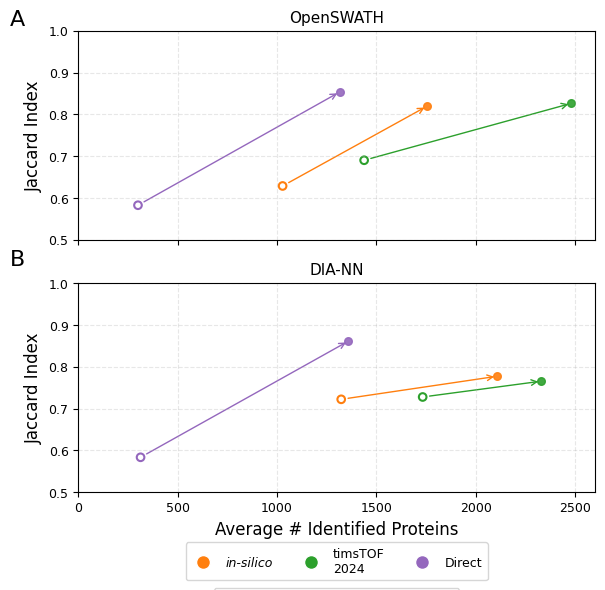

In [8]:
def createID_Reproducibility_plot(df, 
                                  title, 
                                  ax, 
                                  show_legends=True, 
                                  panel_label='', 
                                  show_xlabel=True,
                                  show_ylabel=True,
                                  font_size_small = 9,
                                  font_size_medium = 12,
                                  font_size_large = 14,
                                  font_size_title = 11):
    # Set style
    plt.style.use('default')
    sns.set_palette("husl")
    
    library_colors = {
        names['silico']: '#ff7f0e', 
        names['bruker']: '#2ca02c',
        names['diatracer']: '#9467bd'
    }
    
    point_size=30
    edge_width=1.5
    
    for library in df['Library'].unique():
        lib_data = df[df['Library'] == library]
        original = lib_data[lib_data['Condition'] == condition['orig']]
        refined = lib_data[lib_data['Condition'] == condition['refined']]
        color = library_colors[library]
        
        short_name = library.replace(' Library', '')
        ax.scatter(original['# IDs'], original['Jaccard Index'], 
                     s=point_size, facecolors='none', edgecolors=color, linewidth=edge_width, label=short_name)
        ax.scatter(refined['# IDs'], refined['Jaccard Index'],
                     s=point_size, c=color, alpha=0.9)
                     
        arrow = FancyArrowPatch(
            (original['# IDs'].iloc[0], original['Jaccard Index'].iloc[0]),
            (refined['# IDs'].iloc[0], refined['Jaccard Index'].iloc[0]),
            arrowstyle='->', mutation_scale=10, shrinkA=5, shrinkB=2,
            color=color, alpha=1, linewidth=1
        )
        ax.add_patch(arrow)
        
    if show_xlabel:
        ax.set_xlabel('Average # Identified Proteins', fontsize=font_size_medium)
    else:
        ax.set_xlabel('')
        
    if show_ylabel:
        ax.set_ylabel('Jaccard Index', fontsize=font_size_medium)
    
    x_min, x_max = df['# IDs'].min() - 2000, df['# IDs'].max() + 2000
    y_min, y_max = df['Jaccard Index'].min() - 0.01, df['Jaccard Index'].max() + 0.01
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    ax.tick_params(axis='both', which='major', labelsize=font_size_small)
    ax.tick_params(axis='y', which='major', labelsize=font_size_small)
    
    ax.grid(True, alpha=0.3, linestyle='--')
    
    if panel_label:
        ax.text(0, 1.02, panel_label, transform=ax.transAxes, fontsize=font_size_large, 
                         fontweight='bold', verticalalignment='bottom', horizontalalignment='left')

    if show_legends:
        condition_legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='none', 
                   markeredgecolor='black', markersize=7, markeredgewidth=1.5, 
                   label=condition['orig'], linestyle='None'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
                   markersize=10, alpha=1, label=condition['refined'], linestyle='None'),
        ]
        library_legend_elements = []
        for library, color in library_colors.items():
            short_name = library.replace(' Library', '')
            library_legend_elements.append(
                Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                       markersize=10, alpha=1, label=short_name, 
                       linestyle='None')
            )
        legend1 = ax.legend(handles=condition_legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.6), 
                     fontsize=font_size_small, ncol=2)
        leg = ax.legend(handles=library_legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.45), 
                     fontsize=font_size_small)
        leg.get_texts()[0].set_style('italic')
        ax.add_artist(legend1)

    
    ax.set_xlim(0, 2600)
    ax.set_ylim(0.5, 1.0)
    ax.set_title(title, fontsize=font_size_title)

# We keep the 7x7 figure size
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

createID_Reproducibility_plot(osw_df, title='OpenSWATH', ax=ax1, show_legends=False, panel_label='', show_xlabel=False, show_ylabel=True)
createID_Reproducibility_plot(diann_df, title='DIA-NN', ax=ax2, show_legends=True, panel_label='', show_xlabel=True)

fig.text(0, 0.95, 'A', fontsize=16) 
fig.text(0, 0.55, 'B', fontsize=16) 
plt.tight_layout()
plt.savefig("Figure-S20.png", dpi=300, bbox_inches='tight')